In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
with open("dataset/chat_messages.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

with open("output/summaries.json", "r", encoding="utf-8") as f:
    generated_data = json.load(f)

generated_dict = {item["chat_id"]: item for item in generated_data}

print("Loaded chats:", len(dataset))
print("Loaded summaries:", len(generated_dict))

Loaded chats: 5
Loaded summaries: 5


In [14]:
def summary_dict_to_text(summary_dict):
    text_parts = []

    for section in ["key_topics", "decisions", "important_mentions", "action_items"]:
        items = summary_dict[section]

        if section == "action_items":
            if len(items) > 0 and isinstance(items[0], dict):
                items = [item.get("task", "") for item in items]

        text_parts.extend(items)

    return " ".join(text_parts)


def compute_compression(original_text, summary_text):
    original_words = len(original_text.split())
    summary_words = len(summary_text.split())

    if original_words == 0:
        return 0

    return round(summary_words / original_words, 3)

In [15]:
records = []

for chat in dataset:

    chat_id = chat["chat_id"]

    if chat_id not in generated_dict:
        continue

    generated_entry = generated_dict[chat_id]
    generated_summary = generated_entry["summary"]

    original_text = " ".join(message["message"] for message in chat["messages"])

    summary_text = summary_dict_to_text(generated_summary)

    compression = compute_compression(original_text, summary_text)

    records.append(
        {
            "chat_id": chat_id,
            "message_count": len(chat["messages"]),
            "latency": generated_entry.get("processing_time", 0),
            "token_usage": generated_entry.get("total_tokens", 0),
            "compression_ratio": compression,
        }
    )

df = pd.DataFrame(records)

df

,chat_id,message_count,latency,token_usage,compression_ratio
0,group_001,10,74.82,966,0.889
1,group_002,7,35.56,696,0.581
2,group_003,5,23.97,616,0.318
3,group_004,5,27.84,654,0.625
4,group_005,15,99.70,1453,1.232


In [16]:
df["manual_quality_score"] = [4, 5, 4, 3, 5]

df

,chat_id,message_count,latency,token_usage,compression_ratio,manual_quality_score
0,group_001,10,74.82,966,0.889,4
1,group_002,7,35.56,696,0.581,5
2,group_003,5,23.97,616,0.318,4
3,group_004,5,27.84,654,0.625,3
4,group_005,15,99.70,1453,1.232,5


In [17]:
print("Average Latency:", round(df["latency"].mean(), 3))
print("Average Token Usage:", round(df["token_usage"].mean(), 2))
print("Average Compression Ratio:", round(df["compression_ratio"].mean(), 3))
print("Average Manual Quality Score:", round(df["manual_quality_score"].mean(), 2))

Average Latency: 52.378
Average Token Usage: 877.0
Average Compression Ratio: 0.729
Average Manual Quality Score: 4.2


### Scatter plot - Message count vs latency

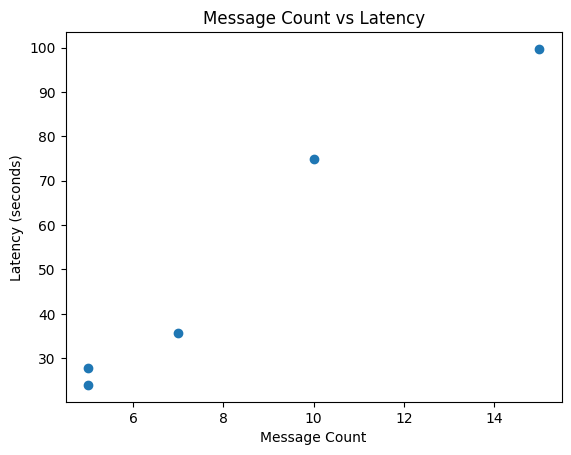

In [18]:
plt.figure()

plt.scatter(df["message_count"], df["latency"])

plt.xlabel("Message Count")
plt.ylabel("Latency (seconds)")
plt.title("Message Count vs Latency")

plt.show()

### Scatter plot - Token usage vs latency

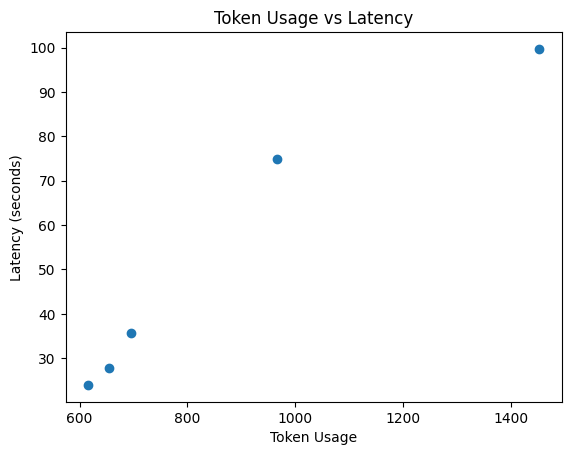

In [19]:
plt.figure()

plt.scatter(df["token_usage"], df["latency"])

plt.xlabel("Token Usage")
plt.ylabel("Latency (seconds)")
plt.title("Token Usage vs Latency")

plt.show()